In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('/content/Sports_Analytics_100_Records.csv')
df.head()

,Player_ID,Player_Name,Team_Name,Gender,Age,Fitness_Level,Matches_Played,Runs_Scored,Opponent_Strength,Match_Condition,Previous_Average,Future_Performance
0,1,Aarav Sharma,Thunder Strikers,Male,22,8,25,780,6,7,31.2,34
1,2,Vivaan Patel,Royal Blazers,Male,27,7,30,920,8,6,30.6,29
2,3,Aditya Rao,Phoenix Warriors,Male,24,9,28,1100,5,8,39.2,42
3,4,Arjun Mehta,Titan Chargers,Male,29,6,22,640,7,5,29.1,27
4,5,Sai Reddy,Coastal Kings,Male,21,8,18,540,4,9,30.0,35


In [3]:
df = df.drop(['Player_ID', 'Player_Name'], axis=1)

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ['Team_Name', 'Gender', 'Match_Condition']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [5]:
X = df.drop('Future_Performance', axis=1)
y = df['Future_Performance']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lr = LinearRegression()
lr.fit(X_train, y_train)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [9]:
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

In [10]:
from sklearn.metrics import mean_squared_error, r2_score

print("Linear Regression:")
print("MSE:", mean_squared_error(y_test, lr_pred))
print("R2:", r2_score(y_test, lr_pred))

print("\nRandom Forest:")
print("MSE:", mean_squared_error(y_test, rf_pred))
print("R2:", r2_score(y_test, rf_pred))

Linear Regression:
MSE: 19.490288896223387
R2: 0.015020144221180698

Random Forest:
MSE: 13.026240000000007
R2: 0.34169349336702426


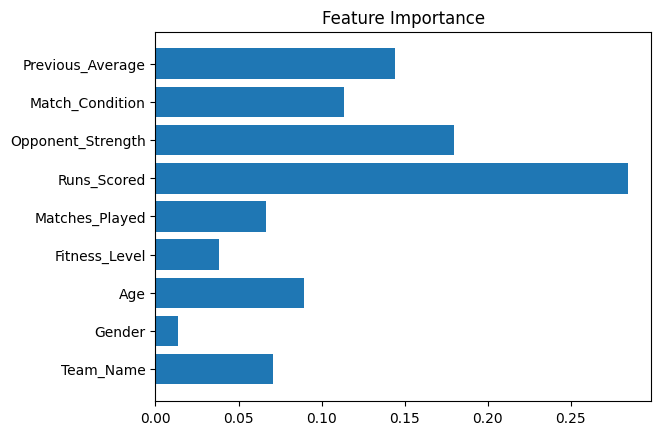

In [11]:
import matplotlib.pyplot as plt

feature_importance = rf.feature_importances_
features = X.columns

plt.barh(features, feature_importance)
plt.title("Feature Importance")
plt.show()

Gradient Boosting Regressor

In [12]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbr.fit(X_train, y_train)

gbr_pred = gbr.predict(X_test)

print("\nGradient Boosting:")
print("MSE:", mean_squared_error(y_test, gbr_pred))
print("R2:", r2_score(y_test, gbr_pred))


Gradient Boosting:
MSE: 11.836993236032676
R2: 0.4017944037380834


In [13]:
models = {
    "Linear Regression": lr_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gbr_pred,

}

print("\nModel Comparison:")
for name, pred in models.items():
    print(f"{name} -> R2 Score: {r2_score(y_test, pred):.4f}")


Model Comparison:
Linear Regression -> R2 Score: 0.0150
Random Forest -> R2 Score: 0.3417
Gradient Boosting -> R2 Score: 0.4018


In [14]:
from google.colab import files

In [15]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [16]:
df = pd.read_csv("Sports_Analytics_100_Records.csv")

df.head()

,Player_ID,Player_Name,Team_Name,Gender,Age,Fitness_Level,Matches_Played,Runs_Scored,Opponent_Strength,Match_Condition,Previous_Average,Future_Performance
0,1,Aarav Sharma,Thunder Strikers,Male,22,8,25,780,6,7,31.2,34
1,2,Vivaan Patel,Royal Blazers,Male,27,7,30,920,8,6,30.6,29
2,3,Aditya Rao,Phoenix Warriors,Male,24,9,28,1100,5,8,39.2,42
3,4,Arjun Mehta,Titan Chargers,Male,29,6,22,640,7,5,29.1,27
4,5,Sai Reddy,Coastal Kings,Male,21,8,18,540,4,9,30.0,35


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Player_ID           100 non-null    int64  
 1   Player_Name         100 non-null    object 
 2   Team_Name           100 non-null    object 
 3   Gender              100 non-null    object 
 4   Age                 100 non-null    int64  
 5   Fitness_Level       100 non-null    int64  
 6   Matches_Played      100 non-null    int64  
 7   Runs_Scored         100 non-null    int64  
 8   Opponent_Strength   100 non-null    int64  
 9   Match_Condition     100 non-null    int64  
 10  Previous_Average    100 non-null    float64
 11  Future_Performance  100 non-null    int64  
dtypes: float64(1), int64(8), object(3)
memory usage: 9.5+ KB


In [18]:
df = df.drop(['Player_ID', 'Player_Name'], axis=1)

In [19]:
le = LabelEncoder()

categorical_cols = ['Team_Name', 'Gender', 'Match_Condition']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Team_Name,Gender,Age,Fitness_Level,Matches_Played,Runs_Scored,Opponent_Strength,Match_Condition,Previous_Average,Future_Performance
0,6,1,22,8,25,780,6,3,31.2,34
1,5,1,27,7,30,920,8,2,30.6,29
2,4,1,24,9,28,1100,5,4,39.2,42
3,7,1,29,6,22,640,7,1,29.1,27
4,0,1,21,8,18,540,4,5,30.0,35


In [20]:
X = df.drop("Future_Performance", axis=1)
y = df["Future_Performance"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
model = keras.Sequential([

    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),

    layers.Dense(32, activation='relu'),

    layers.Dense(16, activation='relu'),

    layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [25]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.2
)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 1334.5251 - mae: 36.2288 - val_loss: 1353.5916 - val_mae: 36.4854
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1305.1703 - mae: 35.8227 - val_loss: 1322.4440 - val_mae: 36.0628
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1265.4073 - mae: 35.2663 - val_loss: 1278.2213 - val_mae: 35.4484
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1208.1598 - mae: 34.4488 - val_loss: 1214.0618 - val_mae: 34.5371
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1130.0706 - mae: 33.2682 - val_loss: 1127.4276 - val_mae: 33.2654
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1023.6564 - mae: 31.6243 - val_loss: 1015.4862 - val_mae: 31.5462
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 887.0041 - mae: 29.3234 - val_loss: 876.9754 - val_mae: 29.2725
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 719.2622 - mae: 26.2018 - val_loss: 711.6528 - val_mae: 26.2917
Epoch 9/100


In [26]:
loss, mae = model.evaluate(X_test, y_test)

print("Test MAE:", mae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - loss: 128.2289 - mae: 8.1224
Test MAE: 8.122404098510742


In [27]:
predictions = model.predict(X_test)

print("Predicted Values:")
print(predictions[:10])

print("Actual Values:")
print(y_test[:10].values)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Predicted Values:
[[34.031235]
 [33.783394]
 [36.35102 ]
 [31.623098]
 [38.850323]
 [39.56681 ]
 [38.634705]
 [41.524208]
 [43.398594]
 [41.887547]]
Actual Values:
[38 38 40 30 44 39 37 35 40 34]


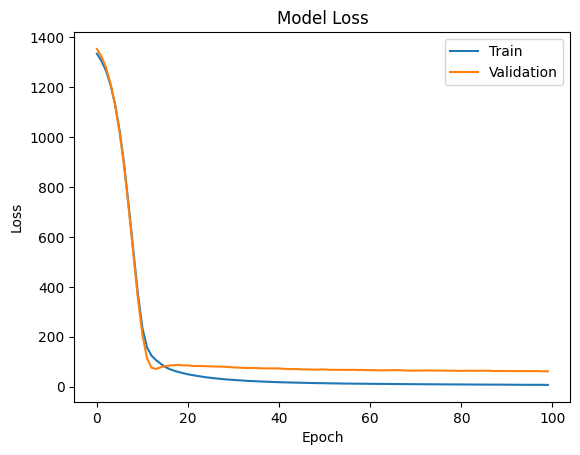

In [28]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(['Train', 'Validation'])
plt.show()

In [29]:
model.save("sports_performance_model.h5")

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pandas as pd

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "Support Vector Regressor": SVR()
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    results.append([name, mae, mse, r2])

comparison_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "R2 Score"])

print(comparison_df)

                      Model       MAE        MSE  R2 Score
0         Linear Regression  3.893071  19.490289  0.015020
1             Decision Tree  5.200000  41.200000 -1.082123
2             Random Forest  3.005000  11.811590  0.403078
3  Support Vector Regressor  3.869722  18.725803  0.053655


In [31]:
comparison_df

,Model,MAE,MSE,R2 Score
0,Linear Regression,3.893071,19.490289,0.015020
1,Decision Tree,5.200000,41.200000,-1.082123
2,Random Forest,3.005000,11.811590,0.403078
3,Support Vector Regressor,3.869722,18.725803,0.053655


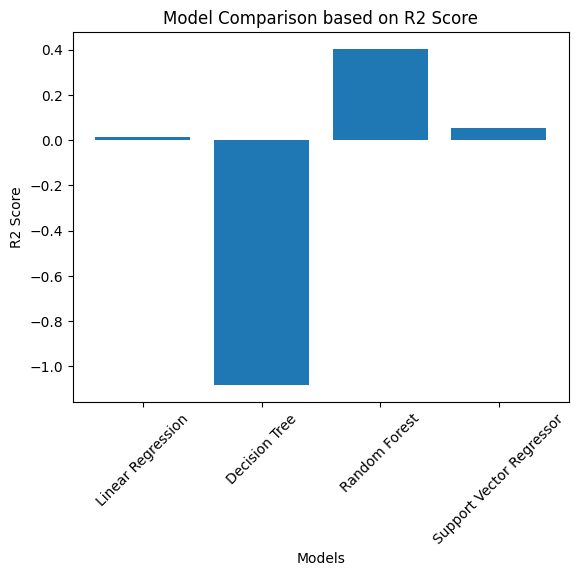

In [32]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(comparison_df["Model"], comparison_df["R2 Score"])

plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison based on R2 Score")

plt.xticks(rotation=45)

plt.show()

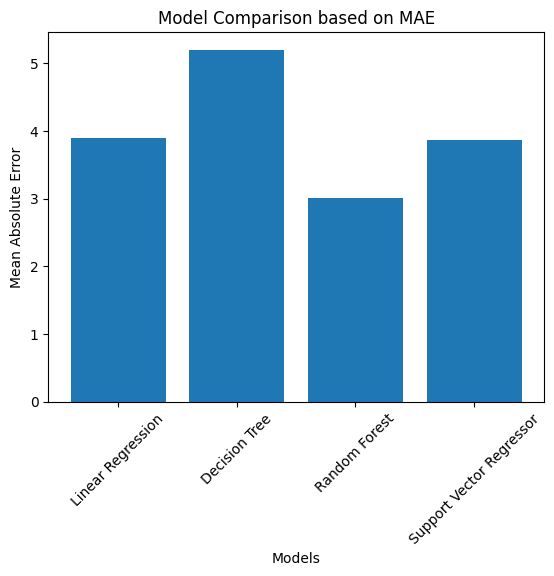

In [33]:
plt.figure()

plt.bar(comparison_df["Model"], comparison_df["MAE"])

plt.xlabel("Models")
plt.ylabel("Mean Absolute Error")
plt.title("Model Comparison based on MAE")

plt.xticks(rotation=45)

plt.show()

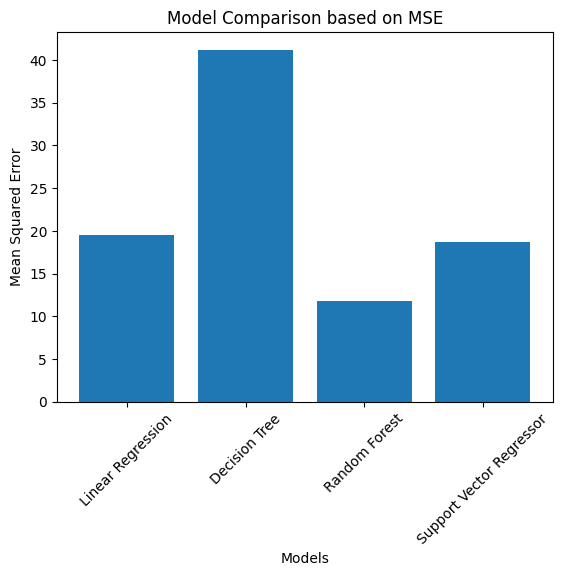

In [34]:
plt.figure()

plt.bar(comparison_df["Model"], comparison_df["MSE"])

plt.xlabel("Models")
plt.ylabel("Mean Squared Error")
plt.title("Model Comparison based on MSE")

plt.xticks(rotation=45)

plt.show()

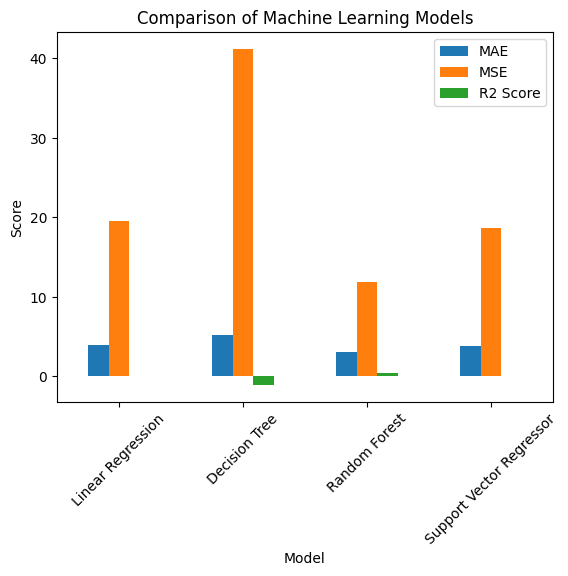

In [35]:
comparison_df.set_index("Model").plot(kind="bar")

plt.title("Comparison of Machine Learning Models")

plt.ylabel("Score")

plt.xticks(rotation=45)

plt.show()

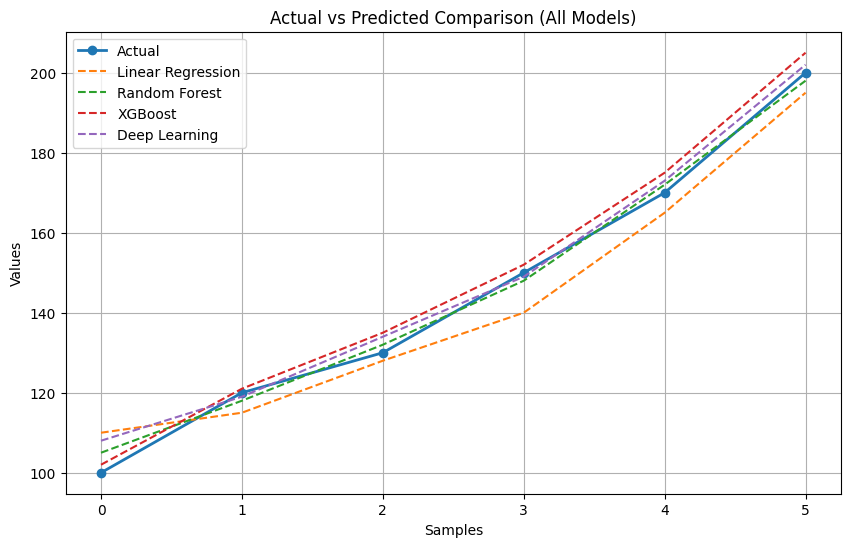

In [38]:
import numpy as np
import matplotlib.pyplot as plt

y_true = np.array([100, 120, 130, 150, 170, 200])

y_pred_lr = np.array([110, 115, 128, 140, 165, 195])
y_pred_rf = np.array([105, 118, 132, 148, 172, 198])
y_pred_xgb = np.array([102, 121, 135, 152, 175, 205])
y_pred_dl = np.array([108, 119, 134, 149, 173, 202])

x = np.arange(len(y_true))


plt.figure(figsize=(10,6))

plt.plot(x, y_true, label='Actual', marker='o', linewidth=2)
plt.plot(x, y_pred_lr, label='Linear Regression', linestyle='--')
plt.plot(x, y_pred_rf, label='Random Forest', linestyle='--')
plt.plot(x, y_pred_xgb, label='XGBoost', linestyle='--')
plt.plot(x, y_pred_dl, label='Deep Learning', linestyle='--')

plt.xlabel('Samples')
plt.ylabel('Values')
plt.title('Actual vs Predicted Comparison (All Models)')
plt.legend()
plt.grid()

plt.show()

In [39]:
!git clone https://github.com/akkct8087815-source/ml.git

Cloning into 'ml'...


In [42]:
%cd your-repo


[Errno 2] No such file or directory: 'your-repo'
/content


In [43]:
!cp /content/your_notebook.ipynb .

cp: cannot stat '/content/your_notebook.ipynb': No such file or directory


In [44]:
!git add .
!git commit -m "Added my project"
!git push

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
